# AmanFood – Food Price Prediction in Egypt

A machine learning project for predicting food prices in Egypt based on
location, commodity, market, supply, demand, inflation, and other factors.

Run `pip install -r requirements.txt` before running this notebook.

##1- Importing Libraries

In [1]:
# Main Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import (
   mean_absolute_error, mean_squared_error, r2_score
)
import warnings

In [2]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", lambda x: "{:,.2f}".format(x))
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

##2.Data Loading

In [3]:
DATA_PATH = "data/Food_Prices_in_Egypt.parquet"  # adjust if your file lives elsewhere
df = pd.read_parquet(DATA_PATH)

In [4]:
df.head()

,Series_ID,Date,Year,Month,Quarter,Week,DayOfWeek,DayOfYear,Season,Is_Ramadan,Annual_Sin,Annual_Cos,Governorate,Region,Market,Market_Type,Latitude,Longitude,Distance_From_Cairo_KM,Logistics_Score,Urbanization,Commodity,Category,Unit,Inflation_Index,Supply_Level,Demand_Level,Supply_Demand_Gap,Supply_Demand_Ratio,Transport_Cost,Price_EGP,Price_Lag_1,Price_Lag_2,Price_Lag_7,Price_Lag_8,Price_Change_1D_Pct,Price_Change_7D_Pct,Rolling_Mean_7,Rolling_Std_7,Rolling_Mean_30,Rolling_Std_30,Historical_Min,Historical_Max,Historical_Median,Expected_Price,Expected_Lower,Expected_Upper,Observed_User_Price,Price_Deviation_Percent,Price_ZScore,Is_Anomaly,Price_Status,Target_Price_1D,Target_Price_Change_1D_Pct,Target_Price_Direction,Split
0,S000058,2022-02-01,2022,2,1,5,1,32,Winter,0,0.51,0.86,Alexandria,Northern,Alexandria Retail Market 1,Retail,31.22,29.93,180.81,0.90,0.96,Beans,Legumes,KG,103.57,76.10,76.10,-0.00,1.00,5.26,52.06,51.49,51.59,52.33,49.62,-0.20,3.76,52.26,1.60,50.45,2.21,46.79,55.27,50.50,50.47,47.49,53.45,49.74,-1.43,-0.33,0,Normal,53.10,2.01,Up,Train
1,S000057,2022-02-01,2022,2,1,5,1,32,Winter,0,0.51,0.86,Alexandria,Northern,Alexandria Retail Market 1,Retail,31.22,29.93,180.81,0.90,0.96,Eggplant,Vegetables,KG,103.57,84.26,73.98,-10.28,0.88,5.10,24.81,25.60,29.66,24.08,26.05,-13.66,-1.71,25.86,2.69,24.84,2.48,19.66,29.66,24.83,24.83,21.48,28.18,25.94,4.44,0.44,0,Normal,24.36,-1.80,Stable,Train
2,S000060,2022-02-01,2022,2,1,5,1,32,Winter,0,0.51,0.86,Alexandria,Northern,Alexandria Retail Market 2,Retail,31.16,29.99,172.06,0.90,0.96,Grapes,Fruits,KG,103.57,68.52,69.00,0.48,1.01,5.00,54.51,51.64,55.11,52.50,49.62,-6.29,4.07,52.73,2.02,50.76,5.21,30.45,58.78,49.83,50.43,43.40,57.46,50.68,0.49,0.05,0,Normal,64.99,19.23,Up,Train
3,S000059,2022-02-01,2022,2,1,5,1,32,Winter,0,0.51,0.86,Alexandria,Northern,Alexandria Retail Market 2,Retail,31.16,29.99,172.06,0.90,0.96,Vegetable Oil,Oils,L,103.57,76.06,77.08,1.03,1.01,5.20,90.33,87.93,90.58,91.74,97.22,-2.93,-9.56,89.10,2.51,87.59,3.11,82.64,97.22,87.46,87.54,83.35,91.73,81.25,-7.19,-2.03,1,Lower,87.03,-3.65,Down,Train
4,S000063,2022-02-01,2022,2,1,5,1,32,Winter,0,0.51,0.86,Alexandria,Northern,Alexandria Retail Market 5,Retail,31.21,29.92,180.89,0.90,0.96,Eggs,Protein,DOZEN,103.57,72.37,72.83,0.46,1.01,6.28,80.66,85.36,84.52,98.68,100.85,0.99,-15.36,89.85,6.77,89.11,6.91,71.08,100.85,89.36,89.20,79.87,98.53,88.47,-0.81,-0.10,0,Normal,83.25,3.22,Up,Train


In [5]:
df.shape

(488718, 56)

In [6]:
df.columns

Index(['Series_ID', 'Date', 'Year', 'Month', 'Quarter', 'Week', 'DayOfWeek',
       'DayOfYear', 'Season', 'Is_Ramadan', 'Annual_Sin', 'Annual_Cos',
       'Governorate', 'Region', 'Market', 'Market_Type', 'Latitude',
       'Longitude', 'Distance_From_Cairo_KM', 'Logistics_Score',
       'Urbanization', 'Commodity', 'Category', 'Unit', 'Inflation_Index',
       'Supply_Level', 'Demand_Level', 'Supply_Demand_Gap',
       'Supply_Demand_Ratio', 'Transport_Cost', 'Price_EGP', 'Price_Lag_1',
       'Price_Lag_2', 'Price_Lag_7', 'Price_Lag_8', 'Price_Change_1D_Pct',
       'Price_Change_7D_Pct', 'Rolling_Mean_7', 'Rolling_Std_7',
       'Rolling_Mean_30', 'Rolling_Std_30', 'Historical_Min', 'Historical_Max',
       'Historical_Median', 'Expected_Price', 'Expected_Lower',
       'Expected_Upper', 'Observed_User_Price', 'Price_Deviation_Percent',
       'Price_ZScore', 'Is_Anomaly', 'Price_Status', 'Target_Price_1D',
       'Target_Price_Change_1D_Pct', 'Target_Price_Direction', 'Split'],
  

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 488718 entries, 0 to 488717
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   Series_ID                   488718 non-null  str     
 1   Date                        488718 non-null  str     
 2   Year                        488718 non-null  int16   
 3   Month                       488718 non-null  int16   
 4   Quarter                     488718 non-null  int16   
 5   Week                        488718 non-null  int16   
 6   DayOfWeek                   488718 non-null  int16   
 7   DayOfYear                   488718 non-null  int16   
 8   Season                      488718 non-null  category
 9   Is_Ramadan                  488718 non-null  int16   
 10  Annual_Sin                  488718 non-null  float32 
 11  Annual_Cos                  488718 non-null  float32 
 12  Governorate                 488718 non-null  category
 13  Region    

##3- Data Cleaning

In this section, we identify and handle missing values, duplicate records, incorrect data types, and invalid values to ensure that the dataset is clean and ready for analysis and modeling.

In [8]:
df.isnull().sum()

Series_ID                        0
Date                             0
Year                             0
Month                            0
Quarter                          0
Week                             0
DayOfWeek                        0
DayOfYear                        0
Season                           0
Is_Ramadan                       0
Annual_Sin                       0
Annual_Cos                       0
Governorate                      0
Region                           0
Market                           0
Market_Type                      0
Latitude                         0
Longitude                        0
Distance_From_Cairo_KM           0
Logistics_Score                  0
Urbanization                     0
Commodity                        0
Category                         0
Unit                             0
Inflation_Index                  0
Supply_Level                  4899
Demand_Level                  4848
Supply_Demand_Gap             9687
Supply_Demand_Ratio 

In [9]:
missing_df = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Pct (%)': (df.isnull().mean()) * 100
})

In [10]:
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Count', ascending=False)
missing_df

,Missing_Count,Missing_Pct (%)
Supply_Demand_Gap,9687,1.98
Supply_Demand_Ratio,9687,1.98
Transport_Cost,7236,1.48
Supply_Level,4899,1.00
Demand_Level,4848,0.99


In [11]:
missing_columns = missing_df.index.tolist()

In [12]:
df[missing_columns].describe()

,Supply_Demand_Gap,Supply_Demand_Ratio,Transport_Cost,Supply_Level,Demand_Level
count,"479,031.00","479,031.00","481,482.00","483,819.00","483,870.00"
mean,-7.32,0.93,6.33,76.82,69.50
std,17.86,0.24,3.77,10.03,10.13
min,-59.22,0.38,1.00,27.46,34.72
25%,-20.91,0.75,3.85,69.63,62.41
50%,-8.83,0.88,5.00,77.06,68.42
75%,4.52,1.07,9.32,84.21,75.10
max,67.97,3.40,18.37,100.00,100.00


In [13]:
df[
    [
        "Supply_Level",
        "Demand_Level",
        "Transport_Cost"
    ]
].corr()

,Supply_Level,Demand_Level,Transport_Cost
Supply_Level,1.00,-0.57,-0.17
Demand_Level,-0.57,1.00,-0.23
Transport_Cost,-0.17,-0.23,1.00


In [14]:
# Compute median fill values from the Train split only, so information
# from validation/test rows never leaks into the imputed values.
train_mask = df["Split"] == "Train"

In [15]:
supply_median = df.loc[train_mask, "Supply_Level"].median()
demand_median = df.loc[train_mask, "Demand_Level"].median()
transport_median = df.loc[train_mask, "Transport_Cost"].median()

In [16]:
# Fill Supply with the Train median
df["Supply_Level"] = df["Supply_Level"].fillna(supply_median)

In [17]:
# Fill Demand with the Train median
df["Demand_Level"] = df["Demand_Level"].fillna(demand_median)

In [18]:
# Fill Transport Cost with the Train median
df["Transport_Cost"] = df["Transport_Cost"].fillna(transport_median)

In [19]:
df[
    [
        "Supply_Level",
        "Demand_Level",
        "Transport_Cost"
    ]
].isnull().sum()

Supply_Level      0
Demand_Level      0
Transport_Cost    0
dtype: int64

In [20]:
df["Supply_Demand_Gap"] = df["Supply_Level"] - df["Demand_Level"]
df["Supply_Demand_Ratio"] = df["Supply_Level"] / df["Demand_Level"]

In [21]:
df[["Transport_Cost"]].describe()

,Transport_Cost
count,"488,718.00"
mean,6.31
std,3.74
min,1.00
25%,3.87
50%,5.00
75%,9.26
max,18.37


In [22]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [23]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

In [24]:
print(df["Date"].dtype)

datetime64[us]


In [25]:
# Check invalid prices
invalid_price = (df["Price_EGP"] <= 0).sum()
print("Invalid Price_EGP values:", invalid_price)

Invalid Price_EGP values: 0


In [26]:
# Check Supply range
invalid_supply = (
    (df["Supply_Level"] < 0) | (df["Supply_Level"] > 100)).sum()

In [27]:
print("Invalid Supply_Level values:", invalid_supply)

Invalid Supply_Level values: 0


In [28]:
# Check demand range
invalid_demand = (
    (df["Demand_Level"] < 0) | (df["Demand_Level"] > 100)).sum()

In [29]:
print("Invalid Demand_Level values:", invalid_demand)

Invalid Demand_Level values: 0


In [30]:
# Check Is_Ramadan values
print(df["Is_Ramadan"].value_counts())

Is_Ramadan
0    448020
1     40698
Name: count, dtype: int64


In [31]:
# Final cleaning check
print("Missing values:", df.isnull().sum().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData shape:", df.shape)

Missing values: 0

Duplicate rows: 0

Data shape: (488718, 56)


In [32]:
# Leakage check: CatBoost/LightGBM/XGBoost all landed on ~the same R2,
# which is a classic sign that one feature is doing most of the work.
# Historical_Median is the prime suspect - check how closely it tracks
# the target before trusting the headline R2 scores.
if "Historical_Median" in df.columns:
    print("\nCorrelation between Historical_Median and Price_EGP:")
    print(df[["Historical_Median", "Price_EGP"]].corr())


Correlation between Historical_Median and Price_EGP:
                   Historical_Median  Price_EGP
Historical_Median               1.00       0.98
Price_EGP                       0.98       1.00


##4- Exploratory Data Analysis (EDA) 📊

The goal of this section is to explore food price patterns and identify relationships between prices, commodities, locations, time, supply, and demand.

In [33]:
categorical_columns = df.select_dtypes(include="category").columns

In [34]:
categorical_columns

Index(['Season', 'Governorate', 'Region', 'Market', 'Market_Type', 'Commodity',
       'Category', 'Unit', 'Target_Price_Direction', 'Split'],
      dtype='str')

In [35]:
for col in categorical_columns:
    print(f"\n{col}:")
    print("Number of unique values:", df[col].nunique())
    print(df[col].unique())


Season:
Number of unique values: 4
['Winter', 'Spring', 'Summer', 'Autumn']
Categories (4, str): ['Autumn', 'Spring', 'Summer', 'Winter']

Governorate:
Number of unique values: 27
['Alexandria', 'Aswan', 'Asyut', 'Beheira', 'Beni Suef', ..., 'Red Sea', 'Sharqia', 'Sohag', 'South Sinai', 'Suez']
Length: 27
Categories (27, str): ['Alexandria', 'Aswan', 'Asyut', 'Beheira', ..., 'Sharqia', 'Sohag', 'South Sinai', 'Suez']

Region:
Number of unique values: 9
['Northern', 'Upper Egypt', 'Greater Cairo', 'Delta', 'Canal', 'Western', 'Desert', 'Sinai', 'Red Sea']
Categories (9, str): ['Canal', 'Delta', 'Desert', 'Greater Cairo', ..., 'Red Sea', 'Sinai', 'Upper Egypt', 'Western']

Market:
Number of unique values: 134
['Alexandria Retail Market 1', 'Alexandria Retail Market 2', 'Alexandria Retail Market 5', 'Alexandria Retail Market 6', 'Alexandria Retail Market 7', ..., 'Suez Retail Market 5', 'Suez Retail Market 6', 'Suez Retail Market 7', 'Suez Supermarket Market 4', 'Suez Wholesale Market 2'

In [36]:
numeric_columns = df.select_dtypes(include="number").columns

In [37]:
datetime_columns = df.select_dtypes(include="datetime").columns

In [38]:
commodity_counts = df["Commodity"].value_counts()
commodity_counts

Commodity
Chickpeas        24293
Eggplant         22864
Eggs             21435
Pepper           21435
Flour            18577
Lentils          18577
Mango            18577
Beef             17148
Chicken          17148
Garlic           17148
Orange           17148
Pasta            17148
Soybean Oil      17148
Carrot           15719
Potato           15719
Guava            14290
Tomato           14290
Vegetable Oil    14290
Yogurt           14290
Banana           12861
Wheat            12861
Corn             11432
Cucumber         11432
Grapes           11432
Onion            11432
Sunflower Oil    11432
Watermelon       11432
Apple            10003
Beans            10003
Cheese           10003
Fish             10003
Milk             10003
Rice              7145
Name: count, dtype: int64

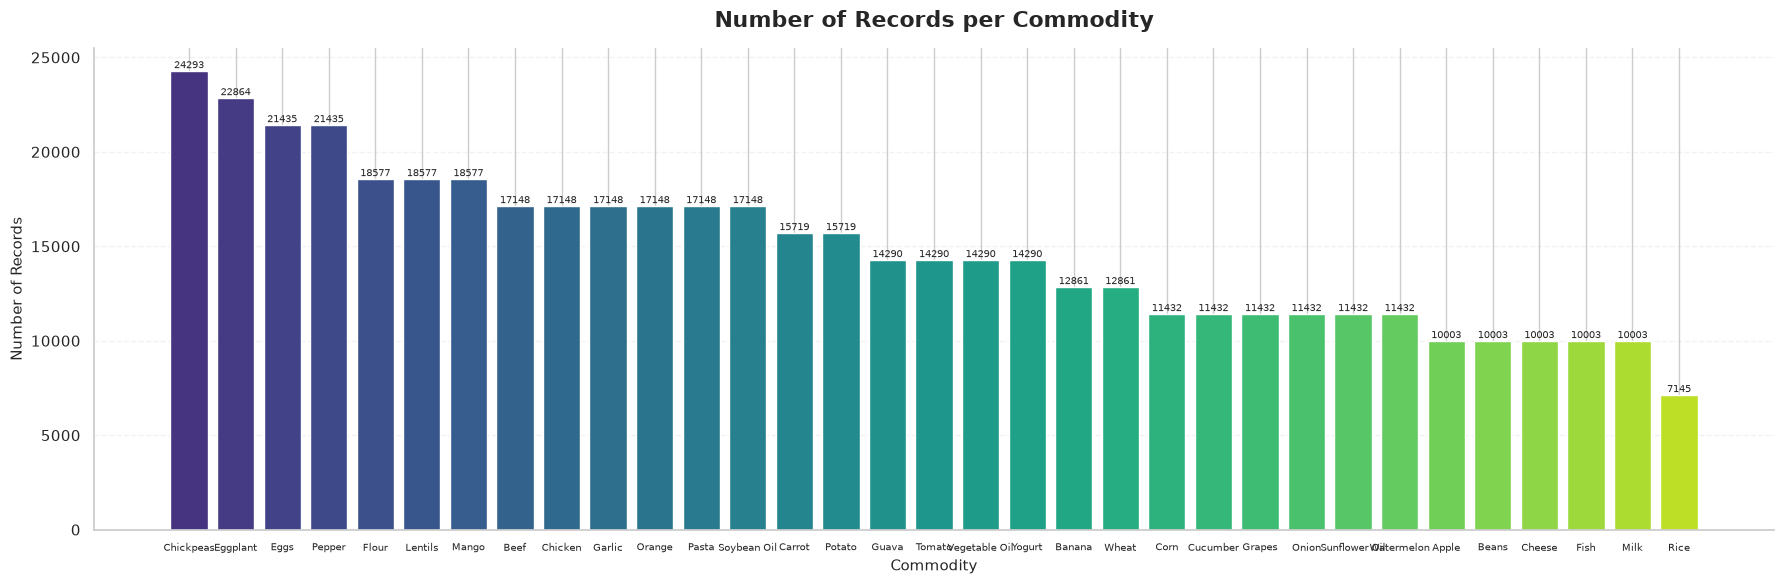

In [39]:
plt.figure(figsize=(18, 6))

bars = plt.bar(
    commodity_counts.index,
    commodity_counts.values,
    color=plt.cm.viridis(
        np.linspace(0.15, 0.9, len(commodity_counts))
    )
)

plt.title(
    "Number of Records per Commodity",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Commodity", fontsize=11)
plt.ylabel("Number of Records", fontsize=11)

# Make names smaller and slightly spaced
plt.xticks(
    rotation=0,
    fontsize=7
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

# Values
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 15,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=7
    )

plt.tight_layout()
plt.show()

In [40]:
# Top 5 commodities by number of records
print("Top 5 commodities:")
print(commodity_counts.head(5))

Top 5 commodities:
Commodity
Chickpeas    24293
Eggplant     22864
Eggs         21435
Pepper       21435
Flour        18577
Name: count, dtype: int64


In [41]:
print("\nBottom 5 commodities:")
print(commodity_counts.tail(5))


Bottom 5 commodities:
Commodity
Beans     10003
Cheese    10003
Fish      10003
Milk      10003
Rice       7145
Name: count, dtype: int64


In [42]:
governorate_counts = df["Governorate"].value_counts()
governorate_counts

Governorate
Cairo             40012
Ismailia          30009
Gharbia           28580
Asyut             27151
Qalyubia          25722
Red Sea           22864
Beheira           21435
Monufia           21435
Damietta          20006
Sharqia           20006
Port Said         18577
Alexandria        17148
Giza              15719
Kafr El Sheikh    15719
Minya             15719
Beni Suef         14290
Dakahlia          14290
Fayoum            14290
Sohag             14290
South Sinai       14290
Aswan             12861
Luxor             12861
Matrouh           12861
Qena              12861
Suez              12861
New Valley        10003
North Sinai        2858
Name: count, dtype: int64

In [43]:
governorate_counts = df["Governorate"].value_counts()

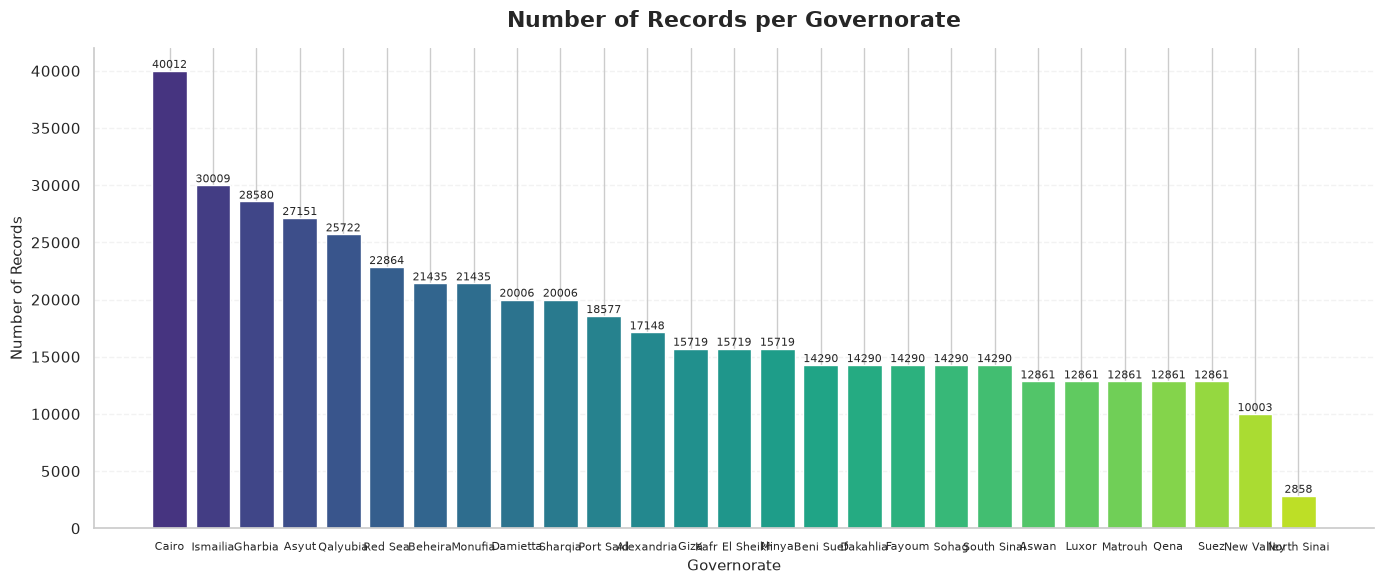

In [44]:
plt.figure(figsize=(14, 6))

bars = plt.bar(
    governorate_counts.index,
    governorate_counts.values,
    color=plt.cm.viridis(
        np.linspace(0.15, 0.9, len(governorate_counts))
    )
)

plt.title(
    "Number of Records per Governorate",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Governorate", fontsize=11)
plt.ylabel("Number of Records", fontsize=11)

plt.xticks(
    rotation=0,
    fontsize=8
)

# Remove unnecessary borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Light grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

# Add values on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 10,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [45]:
print("Top 5 Governorates:")
print(governorate_counts.head(5))

Top 5 Governorates:
Governorate
Cairo       40012
Ismailia    30009
Gharbia     28580
Asyut       27151
Qalyubia    25722
Name: count, dtype: int64


In [46]:
print("\nBottom 5 Governorates:")
print(governorate_counts.tail(5))


Bottom 5 Governorates:
Governorate
Matrouh        12861
Qena           12861
Suez           12861
New Valley     10003
North Sinai     2858
Name: count, dtype: int64


In [47]:
price_stats = df["Price_EGP"].describe()
price_stats

count   488,718.00
mean         80.51
std         100.05
min           5.45
25%          31.05
50%          51.37
75%          92.69
max         891.93
Name: Price_EGP, dtype: float64

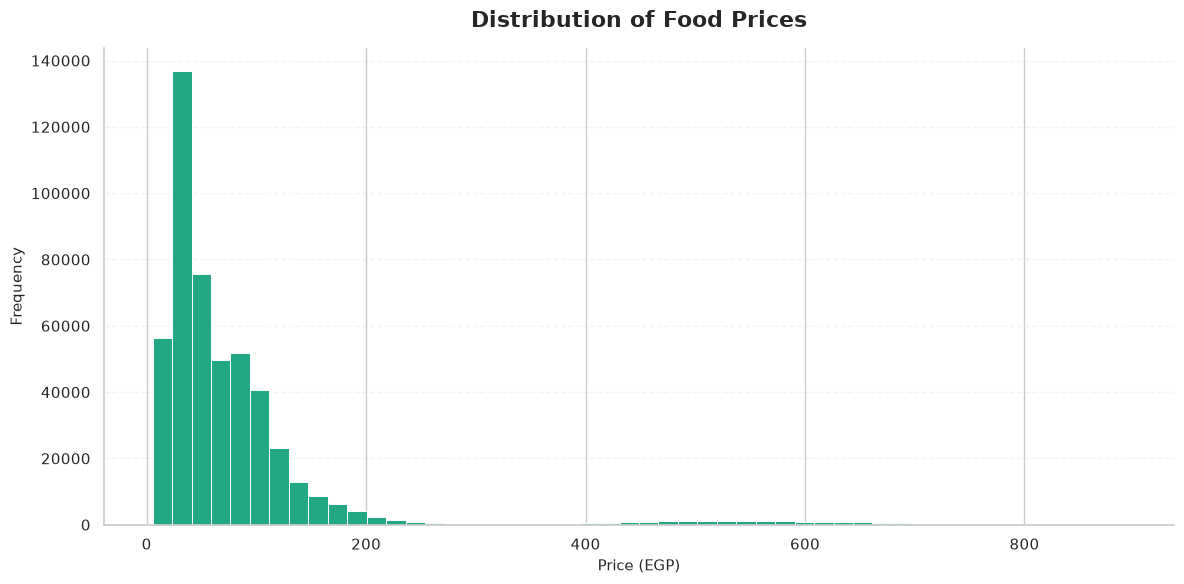

In [48]:
plt.figure(figsize=(12, 6))

plt.hist(
    df["Price_EGP"].dropna(),
    bins=50,
    color=plt.cm.viridis(0.6),
    edgecolor="white",
    linewidth=0.7
)

plt.title(
    "Distribution of Food Prices",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Price (EGP)", fontsize=11)
plt.ylabel("Frequency", fontsize=11)

# Remove unnecessary borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Light grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()

### Price Analysis by Governorate

#### Average and Median Price by Governorate

In [49]:
governorate_price_stats = (
    df.groupby("Governorate", observed=True)["Price_EGP"]
      .agg(["count", "mean", "median", "min", "max"])
      .sort_values("median", ascending=False)
)

In [50]:
governorate_price_stats

,count,mean,median,min,max
Governorate,,,,,
Sohag,14290,120.57,81.04,9.91,845.51
North Sinai,2858,105.33,80.91,14.39,254.48
Suez,12861,73.12,78.62,14.19,174.71
Giza,15719,120.44,77.28,17.26,795.18
Alexandria,17148,84.30,71.46,8.84,334.84
Damietta,20006,104.55,70.67,9.88,831.41
Qena,12861,69.05,65.89,7.85,173.05
Sharqia,20006,107.88,63.18,6.24,771.60
Cairo,40012,95.52,57.60,9.07,858.78


In [51]:
print("Top 5 Governorates by Median Price:")
print(governorate_price_stats["median"].head(5))

Top 5 Governorates by Median Price:
Governorate
Sohag         81.04
North Sinai   80.91
Suez          78.62
Giza          77.28
Alexandria    71.46
Name: median, dtype: float32


In [52]:
print("\nBottom 5 Governorates by Median Price:")
print(governorate_price_stats["median"].tail(5))


Bottom 5 Governorates by Median Price:
Governorate
Minya      41.65
Beheira    40.52
Ismailia   37.57
Matrouh    37.32
Qalyubia   34.85
Name: median, dtype: float32


In [53]:
governorate_price_stats = (
    df.groupby("Governorate", observed=True)["Price_EGP"]
      .agg(["count", "mean", "median", "min", "max"])
      .sort_values("median", ascending=False)
)

In [54]:
median_governorate = governorate_price_stats["median"].sort_values()

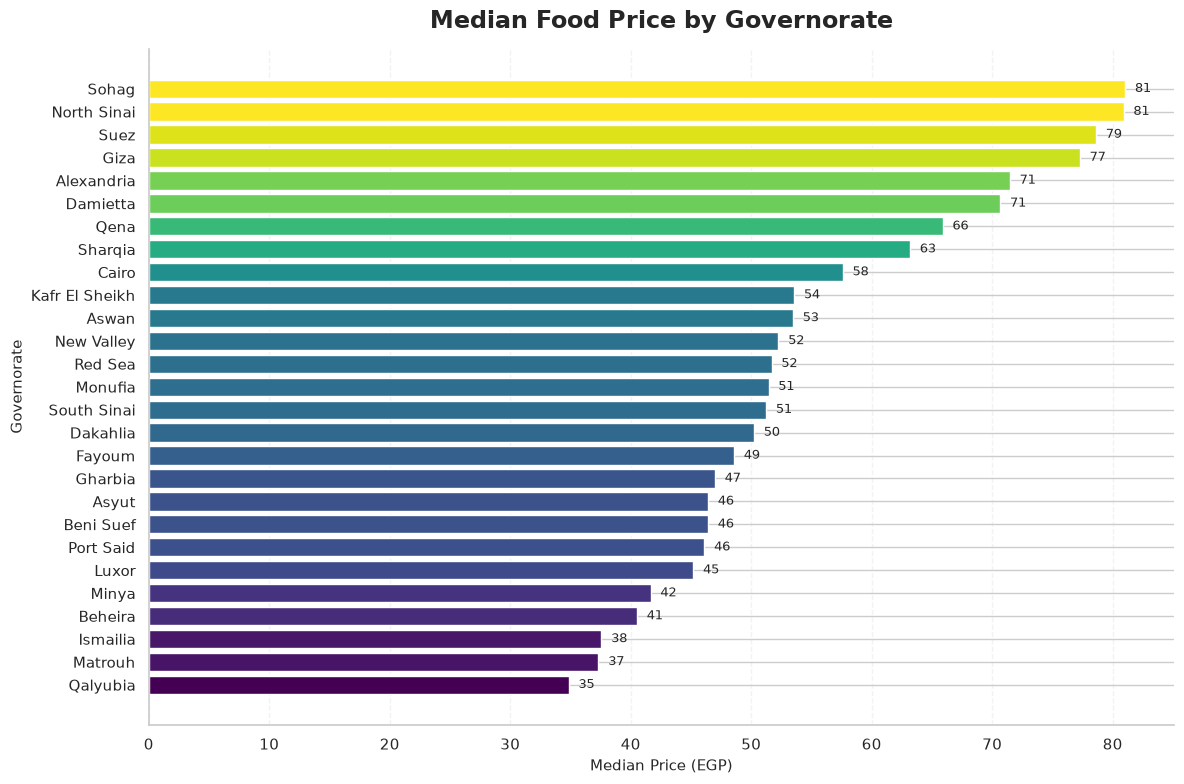

In [55]:
plt.figure(figsize=(12, 8))

bars = plt.barh(
    median_governorate.index,
    median_governorate.values,
    color=plt.cm.viridis(
        (median_governorate.values - median_governorate.values.min()) /
        (median_governorate.values.max() - median_governorate.values.min())
    )
)

plt.title(
    "Median Food Price by Governorate",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Median Price (EGP)", fontsize=11)
plt.ylabel("Governorate", fontsize=11)

# Add values
for bar, value in zip(bars, median_governorate.values):
    plt.text(
        value + median_governorate.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.0f}",
        va="center",
        fontsize=9
    )

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [56]:
price_heatmap = (
    df.pivot_table(
        index="Governorate",
        columns="Commodity",
        values="Price_EGP",
        aggfunc="median",
        observed=True
    )
)

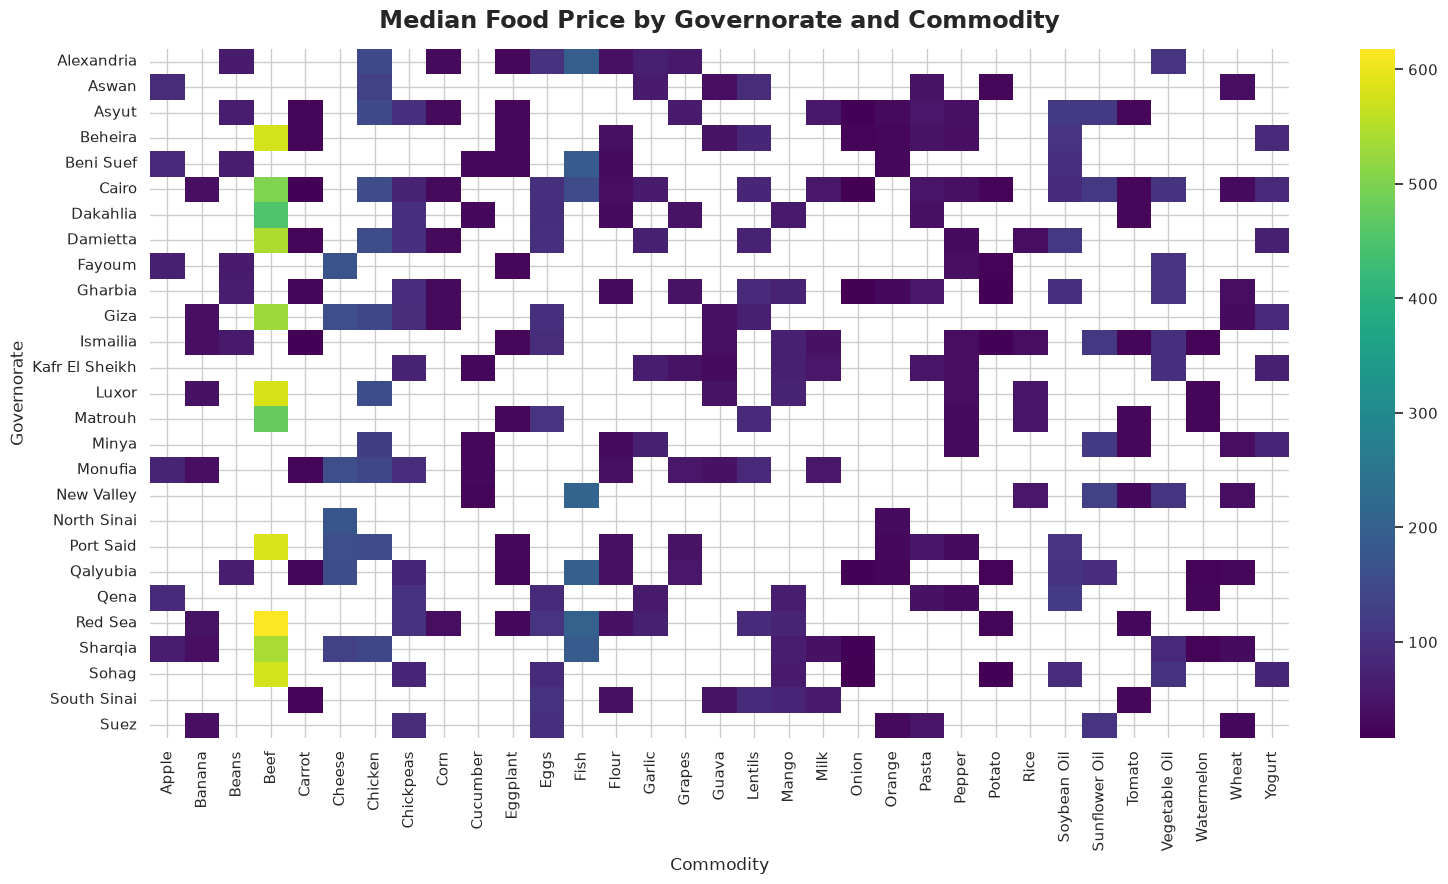

In [57]:
plt.figure(figsize=(16, 9))

sns.heatmap(
    price_heatmap,
    cmap="viridis",
    annot=False
)

plt.title(
    "Median Food Price by Governorate and Commodity",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Commodity")
plt.ylabel("Governorate")

plt.tight_layout()
plt.show()

In [58]:
monthly_price = (
    df.groupby("Date", observed=True)["Price_EGP"]
      .median()
)

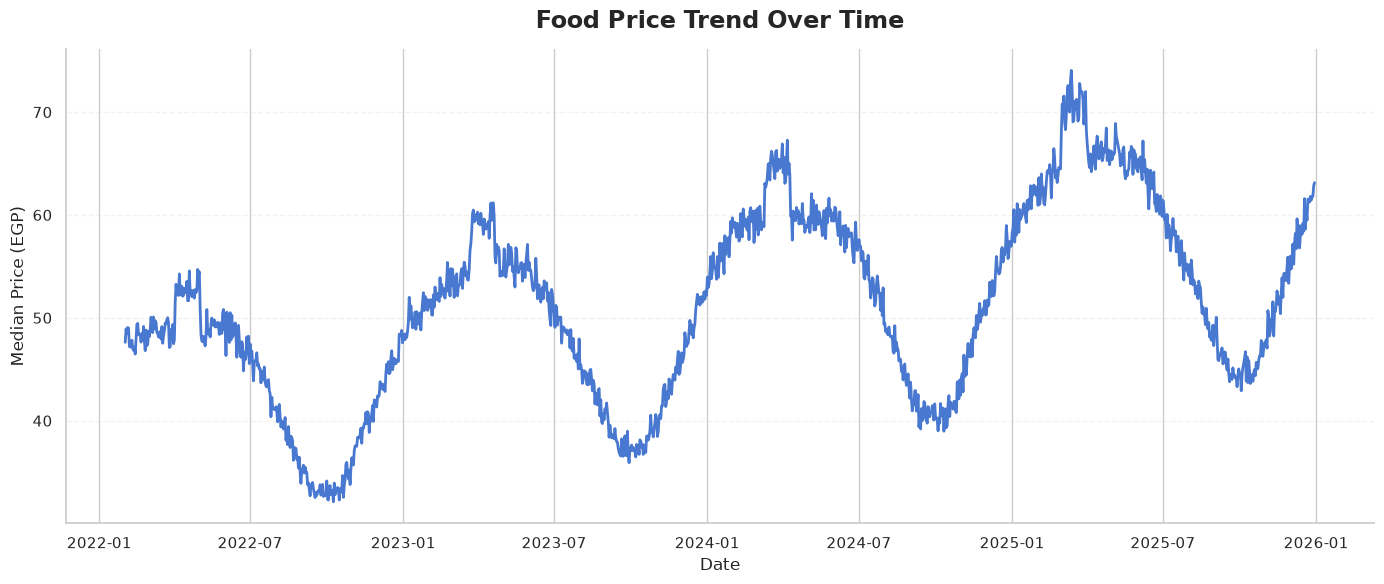

In [59]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_price.index,
    monthly_price.values,
    linewidth=2
)

plt.title(
    "Food Price Trend Over Time",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Date")
plt.ylabel("Median Price (EGP)")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [60]:
monthly_seasonality = (
    df.groupby("Month", observed=True)["Price_EGP"]
      .median()
)

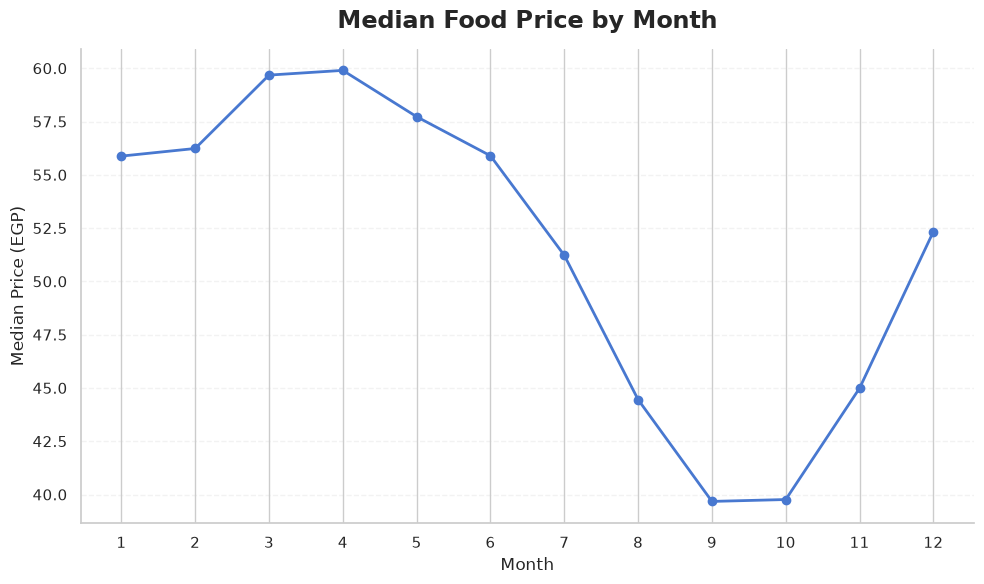

In [61]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_seasonality.index,
    monthly_seasonality.values,
    marker="o",
    linewidth=2
)

plt.title(
    "Median Food Price by Month",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Month")
plt.ylabel("Median Price (EGP)")

plt.xticks(range(1, 13))

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [62]:
ramadan_prices = (
    df.groupby("Is_Ramadan", observed=True)["Price_EGP"]
      .median()
)

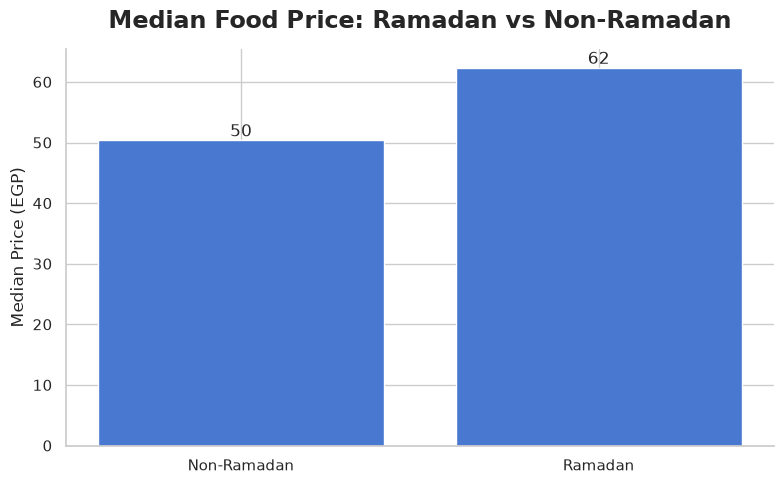

In [63]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    ["Non-Ramadan", "Ramadan"],
    ramadan_prices.values
)

plt.title(
    "Median Food Price: Ramadan vs Non-Ramadan",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.ylabel("Median Price (EGP)")

for bar, value in zip(bars, ramadan_prices.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.0f}",
        ha="center",
        va="bottom"
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [64]:
numeric_cols = [
    "Price_EGP",
    "Transport_Cost",
    "Inflation_Index",
]

In [65]:
corr = df[numeric_cols].corr()

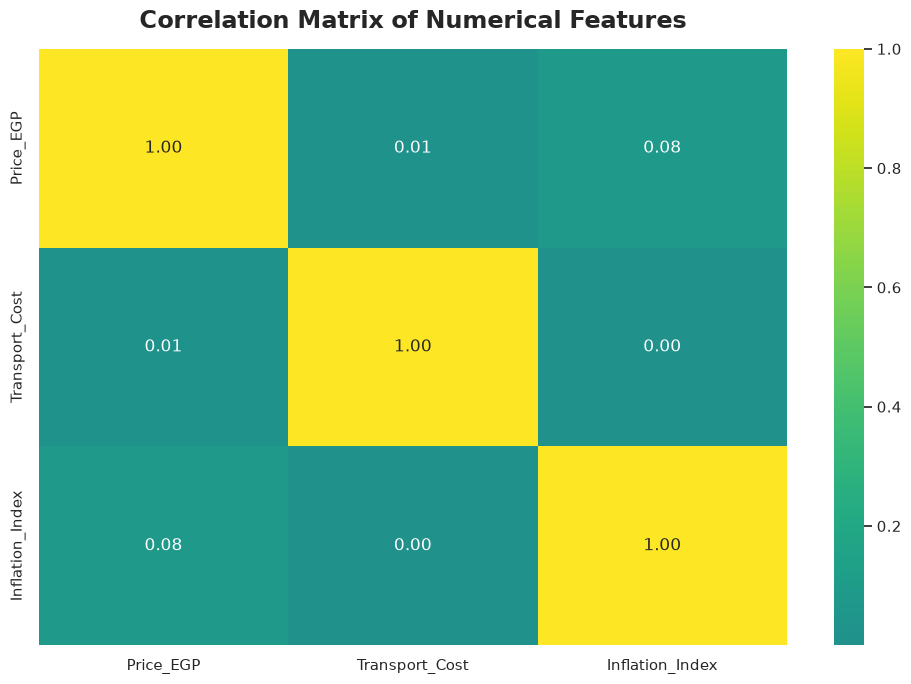

In [66]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    center=0
)

plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

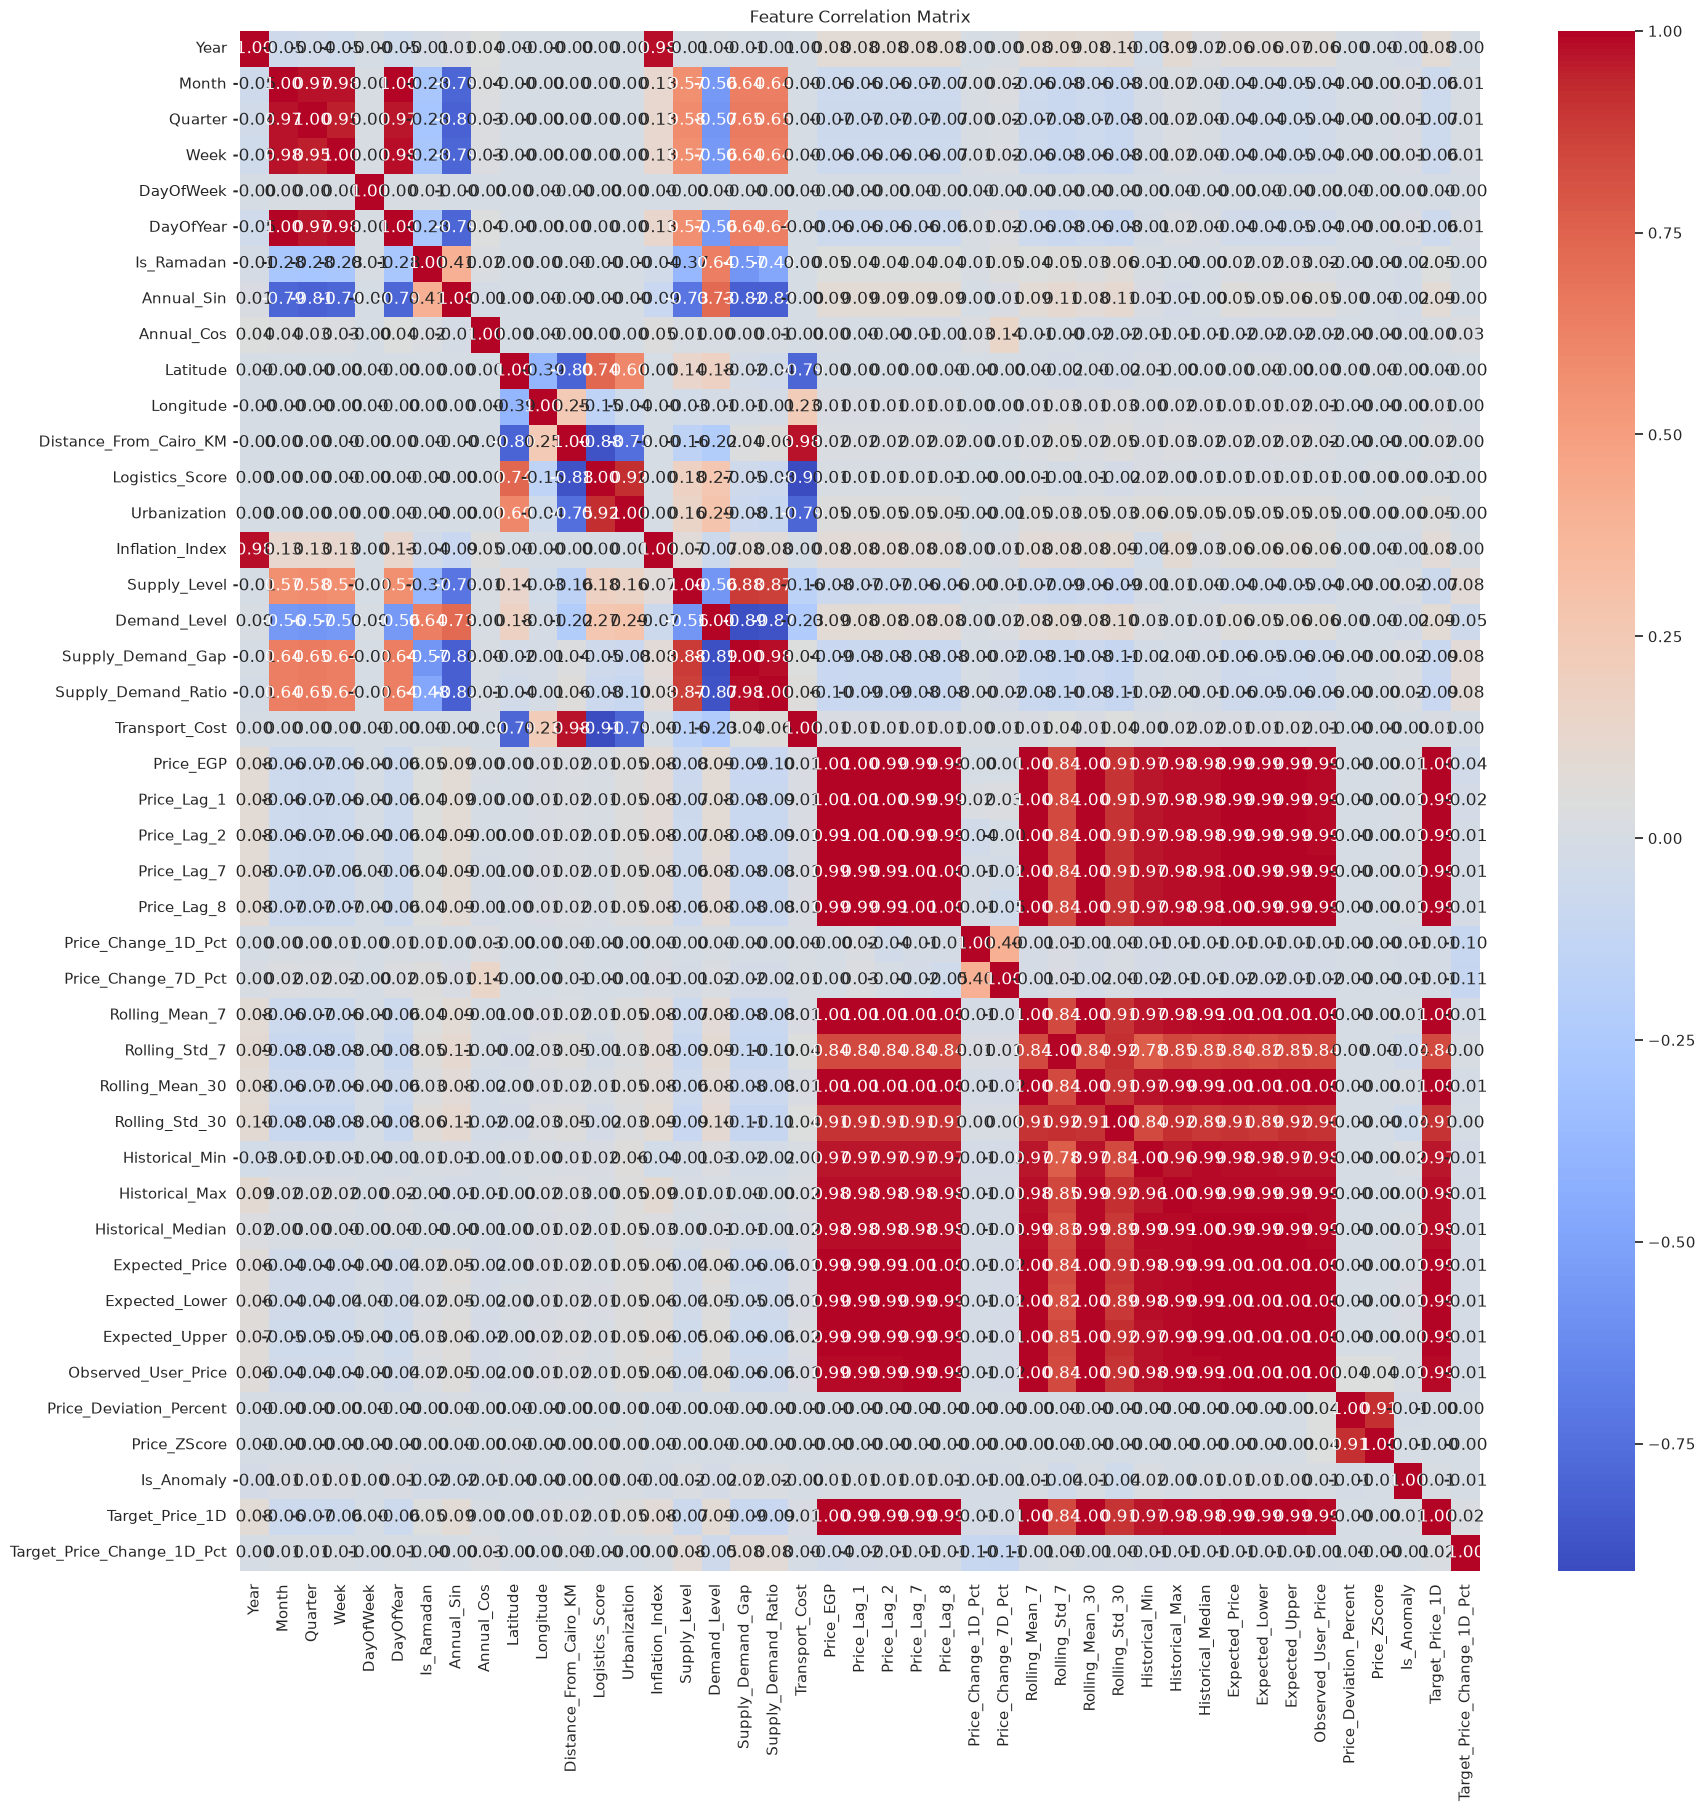

In [67]:
plt.figure(figsize=(20, 20))
sns.heatmap(df.corr(numeric_only=True), annot=True,fmt='.2f', cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [68]:
df.isnull().sum()

Series_ID                     0
Date                          0
Year                          0
Month                         0
Quarter                       0
Week                          0
DayOfWeek                     0
DayOfYear                     0
Season                        0
Is_Ramadan                    0
Annual_Sin                    0
Annual_Cos                    0
Governorate                   0
Region                        0
Market                        0
Market_Type                   0
Latitude                      0
Longitude                     0
Distance_From_Cairo_KM        0
Logistics_Score               0
Urbanization                  0
Commodity                     0
Category                      0
Unit                          0
Inflation_Index               0
Supply_Level                  0
Demand_Level                  0
Supply_Demand_Gap             0
Supply_Demand_Ratio           0
Transport_Cost                0
Price_EGP                     0
Price_La

##5-Data Preprocessing 🔧

This section prepares the data for machine learning by removing
unnecessary and leakage-prone features, encoding categorical variables,
splitting the data, and scaling the features.

### 5.1 Dropping Unnecessary & Leakage-Prone Features 🗑️

In [69]:
#drop some features that start with same target
columns_to_drop = [
    'Series_ID', 'Date',
    'Expected_Price', 'Expected_Lower', 'Expected_Upper',
    'Observed_User_Price', 'Price_Deviation_Percent', 'Price_ZScore',
    'Is_Anomaly', 'Price_Status','Price_Changed per 3days',
    'Target_Price_1D','Target_Price_Change_1D_Pct', 'Target_Price_Direction',
    'Price_Lag_1', 'Price_Lag_2', 'Price_Lag_7', 'Price_Lag_8',
    'Price_Change_1D_Pct', 'Price_Change_7D_Pct',
    'Rolling_Mean_7', 'Rolling_Std_7', 'Rolling_Mean_30', 'Rolling_Std_30',
    'Historical_Min', 'Historical_Max',
    'Quarter', 'Week', 'DayOfWeek', 'DayOfYear',
    'Latitude', 'Longitude', 'Distance_From_Cairo_KM', 'Logistics_Score',
    'Supply_Demand_Ratio', 'Market','Supply_Demand_Gap',
    # Historical_Median correlates 0.98 with Price_EGP - keeping it would let
    # every model just echo this one column instead of learning from supply,
    # demand, transport cost, inflation, etc. Dropped to get an honest score.
    'Historical_Median'
]

In [70]:
df= df.drop(columns=[col for col in columns_to_drop if col in df.columns])

In [71]:
print("=:", df.shape)
print("\n:")
print(df.columns.tolist())

=: (488718, 19)

:
['Year', 'Month', 'Season', 'Is_Ramadan', 'Annual_Sin', 'Annual_Cos', 'Governorate', 'Region', 'Market_Type', 'Urbanization', 'Commodity', 'Category', 'Unit', 'Inflation_Index', 'Supply_Level', 'Demand_Level', 'Transport_Cost', 'Price_EGP', 'Split']


In [72]:
#display data
df.head()

,Year,Month,Season,Is_Ramadan,Annual_Sin,Annual_Cos,Governorate,Region,Market_Type,Urbanization,Commodity,Category,Unit,Inflation_Index,Supply_Level,Demand_Level,Transport_Cost,Price_EGP,Split
0,2022,2,Winter,0,0.51,0.86,Alexandria,Northern,Retail,0.96,Beans,Legumes,KG,103.57,76.10,76.10,5.26,52.06,Train
1,2022,2,Winter,0,0.51,0.86,Alexandria,Northern,Retail,0.96,Eggplant,Vegetables,KG,103.57,84.26,73.98,5.10,24.81,Train
2,2022,2,Winter,0,0.51,0.86,Alexandria,Northern,Retail,0.96,Grapes,Fruits,KG,103.57,68.52,69.00,5.00,54.51,Train
3,2022,2,Winter,0,0.51,0.86,Alexandria,Northern,Retail,0.96,Vegetable Oil,Oils,L,103.57,76.06,77.08,5.20,90.33,Train
4,2022,2,Winter,0,0.51,0.86,Alexandria,Northern,Retail,0.96,Eggs,Protein,DOZEN,103.57,72.37,72.83,6.28,80.66,Train


### 5.2 Encoding Categorical Variables 🔤

In [73]:
df_encoded = pd.get_dummies(df, columns=['Season','Governorate','Region','Commodity','Market_Type','Category','Unit'], drop_first=True)
df_encoded.head()

,Year,Month,Is_Ramadan,Annual_Sin,Annual_Cos,Urbanization,Inflation_Index,Supply_Level,Demand_Level,Transport_Cost,Price_EGP,Split,Season_Spring,Season_Summer,Season_Winter,Governorate_Aswan,Governorate_Asyut,Governorate_Beheira,Governorate_Beni Suef,Governorate_Cairo,Governorate_Dakahlia,Governorate_Damietta,Governorate_Fayoum,Governorate_Gharbia,Governorate_Giza,Governorate_Ismailia,Governorate_Kafr El Sheikh,Governorate_Luxor,Governorate_Matrouh,Governorate_Minya,Governorate_Monufia,Governorate_New Valley,Governorate_North Sinai,Governorate_Port Said,Governorate_Qalyubia,Governorate_Qena,Governorate_Red Sea,Governorate_Sharqia,Governorate_Sohag,Governorate_South Sinai,Governorate_Suez,Region_Delta,Region_Desert,Region_Greater Cairo,Region_Northern,Region_Red Sea,Region_Sinai,Region_Upper Egypt,Region_Western,Commodity_Banana,Commodity_Beans,Commodity_Beef,Commodity_Carrot,Commodity_Cheese,Commodity_Chicken,Commodity_Chickpeas,Commodity_Corn,Commodity_Cucumber,Commodity_Eggplant,Commodity_Eggs,Commodity_Fish,Commodity_Flour,Commodity_Garlic,Commodity_Grapes,Commodity_Guava,Commodity_Lentils,Commodity_Mango,Commodity_Milk,Commodity_Onion,Commodity_Orange,Commodity_Pasta,Commodity_Pepper,Commodity_Potato,Commodity_Rice,Commodity_Soybean Oil,Commodity_Sunflower Oil,Commodity_Tomato,Commodity_Vegetable Oil,Commodity_Watermelon,Commodity_Wheat,Commodity_Yogurt,Market_Type_Supermarket,Market_Type_Wholesale,Category_Fruits,Category_Grains,Category_Legumes,Category_Oils,Category_Protein,Category_Vegetables,Unit_KG,Unit_L
0,2022,2,0,0.51,0.86,0.96,103.57,76.10,76.10,5.26,52.06,Train,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False
1,2022,2,0,0.51,0.86,0.96,103.57,84.26,73.98,5.10,24.81,Train,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False
2,2022,2,0,0.51,0.86,0.96,103.57,68.52,69.00,5.00,54.51,Train,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False
3,2022,2,0,0.51,0.86,0.96,103.57,76.06,77.08,5.20,90.33,Train,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True
4,2022,2,0,0.51,0.86,0.96,103.57,72.37,72.83,6.28,80.66,Train,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False

### 5.3 Duplicate Check

In [74]:
print("duplicated columns", df.duplicated().sum())

duplicated columns 0


### 5.4 Train / Validation / Test Split

In [75]:
#split data
train_df = df_encoded [df["Split"] == "Train"].copy()
valid_df = df_encoded [df["Split"] == "Validation"].copy()
test_df = df_encoded [df["Split"] == "Test"].copy()

In [76]:
print(train_df.shape , valid_df.shape , test_df.shape)

(239058, 91) (125172, 91) (124488, 91)


In [77]:
target_column = 'Price_EGP'

In [78]:
X_train = train_df.drop(columns=[target_column, 'Split'], errors='ignore')
y_train = train_df[target_column]

In [79]:
X_val = valid_df.drop(columns=[target_column, 'Split'], errors='ignore')
y_val = valid_df[target_column]

In [80]:
X_test = test_df.drop(columns=[target_column, 'Split'], errors='ignore')
y_test = test_df[target_column]

### 5.5 Feature Scaling

In [81]:
scaler=StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_val_scaled= scaler.transform(X_val)
X_test_scaled= scaler.transform(X_test)
pd.DataFrame(X_train_scaled, columns=X_train.columns).head()

,Year,Month,Is_Ramadan,Annual_Sin,Annual_Cos,Urbanization,Inflation_Index,Supply_Level,Demand_Level,Transport_Cost,Season_Spring,Season_Summer,Season_Winter,Governorate_Aswan,Governorate_Asyut,Governorate_Beheira,Governorate_Beni Suef,Governorate_Cairo,Governorate_Dakahlia,Governorate_Damietta,Governorate_Fayoum,Governorate_Gharbia,Governorate_Giza,Governorate_Ismailia,Governorate_Kafr El Sheikh,Governorate_Luxor,Governorate_Matrouh,Governorate_Minya,Governorate_Monufia,Governorate_New Valley,Governorate_North Sinai,Governorate_Port Said,Governorate_Qalyubia,Governorate_Qena,Governorate_Red Sea,Governorate_Sharqia,Governorate_Sohag,Governorate_South Sinai,Governorate_Suez,Region_Delta,Region_Desert,Region_Greater Cairo,Region_Northern,Region_Red Sea,Region_Sinai,Region_Upper Egypt,Region_Western,Commodity_Banana,Commodity_Beans,Commodity_Beef,Commodity_Carrot,Commodity_Cheese,Commodity_Chicken,Commodity_Chickpeas,Commodity_Corn,Commodity_Cucumber,Commodity_Eggplant,Commodity_Eggs,Commodity_Fish,Commodity_Flour,Commodity_Garlic,Commodity_Grapes,Commodity_Guava,Commodity_Lentils,Commodity_Mango,Commodity_Milk,Commodity_Onion,Commodity_Orange,Commodity_Pasta,Commodity_Pepper,Commodity_Potato,Commodity_Rice,Commodity_Soybean Oil,Commodity_Sunflower Oil,Commodity_Tomato,Commodity_Vegetable Oil,Commodity_Watermelon,Commodity_Wheat,Commodity_Yogurt,Market_Type_Supermarket,Market_Type_Wholesale,Category_Fruits,Category_Grains,Category_Legumes,Category_Oils,Category_Protein,Category_Vegetables,Unit_KG,Unit_L
0,-1.05,-1.44,-0.30,0.72,1.31,1.40,-1.58,-0.08,0.65,-0.28,-0.60,-0.60,1.92,-0.16,-0.24,-0.21,-0.17,-0.30,-0.17,-0.21,-0.17,-0.25,-0.18,-0.26,-0.18,-0.16,-0.16,-0.18,-0.21,-0.14,-0.08,-0.20,-0.24,-0.16,-0.22,-0.21,-0.17,-0.17,-0.16,-0.54,-0.14,-0.36,2.36,-0.22,-0.19,-0.58,-0.16,-0.16,6.92,-0.19,-0.18,-0.14,-0.19,-0.23,-0.15,-0.15,-0.22,-0.21,-0.14,-0.20,-0.19,-0.15,-0.17,-0.20,-0.20,-0.14,-0.15,-0.19,-0.19,-0.21,-0.18,-0.12,-0.19,-0.15,-0.17,-0.17,-0.15,-0.16,-0.17,-0.58,-0.58,-0.49,-0.40,2.87,-0.31,-0.39,-0.60,0.42,-0.35
1,-1.05,-1.44,-0.30,0.72,1.31,1.40,-1.58,0.74,0.45,-0.32,-0.60,-0.60,1.92,-0.16,-0.24,-0.21,-0.17,-0.30,-0.17,-0.21,-0.17,-0.25,-0.18,-0.26,-0.18,-0.16,-0.16,-0.18,-0.21,-0.14,-0.08,-0.20,-0.24,-0.16,-0.22,-0.21,-0.17,-0.17,-0.16,-0.54,-0.14,-0.36,2.36,-0.22,-0.19,-0.58,-0.16,-0.16,-0.14,-0.19,-0.18,-0.14,-0.19,-0.23,-0.15,-0.15,4.51,-0.21,-0.14,-0.20,-0.19,-0.15,-0.17,-0.20,-0.20,-0.14,-0.15,-0.19,-0.19,-0.21,-0.18,-0.12,-0.19,-0.15,-0.17,-0.17,-0.15,-0.16,-0.17,-0.58,-0.58,-0.49,-0.40,-0.35,-0.31,-0.39,1.66,0.42,-0.35
2,-1.05,-1.44,-0.30,0.72,1.31,1.40,-1.58,-0.83,-0.05,-0.35,-0.60,-0.60,1.92,-0.16,-0.24,-0.21,-0.17,-0.30,-0.17,-0.21,-0.17,-0.25,-0.18,-0.26,-0.18,-0.16,-0.16,-0.18,-0.21,-0.14,-0.08,-0.20,-0.24,-0.16,-0.22,-0.21,-0.17,-0.17,-0.16,-0.54,-0.14,-0.36,2.36,-0.22,-0.19,-0.58,-0.16,-0.16,-0.14,-0.19,-0.18,-0.14,-0.19,-0.23,-0.15,-0.15,-0.22,-0.21,-0.14,-0.20,-0.19,6.46,-0.17,-0.20,-0.20,-0.14,-0.15,-0.19,-0.19,-0.21,-0.18,-0.12,-0.19,-0.15,-0.17,-0.17,-0.15,-0.16,-0.17,-0.58,-0.58,2.03,-0.40,-0.35,-0.31,-0.39,-0.60,0.42,-0.35
3,-1.05,-1.44,-0.30,0.72,1.31,1.40,-1.58,-0.08,0.75,-0.30,-0.60,-0.60,1.92,-0.16,-0.24,-0.21,-0.17,-0.30,-0.17,-0.21,-0.17,-0.25,-0.18,-0.26,-0.18,-0.16,-0.16,-0.18,-0.21,-0.14,-0.08,-0.20,-0.24,-0.16,-0.22,-0.21,-0.17,-0.17,-0.16,-0.54,-0.14,-0.36,2.36,-0.22,-0.19,-0.58,-0.16,-0.16,-0.14,-0.19,-0.18,-0.14,-0.19,-0.23,-0.15,-0.15,-0.22,-0.21,-0.14,-0.20,-0.19,-0.15,-0.17,-0.20,-0.20,-0.14,-0.15,-0.19,-0.19,-0.21,-0.18,-0.12,-0.19,-0.15,-0.17,5.76,-0.15,-0.16,-0.17,-0.58,-0.58,-0.49,-0.40,-0.35,3.22,-0.39,-0.60,-2.36,2.87
4,-1.05,-1.44,-0.30,0.72,1.31,1.40,-1.58,-0.45,0.33,-0.01,-0.60,-0.60,1.92,-0.16,-0.24,-0.21,-0.17,-0.30,-0.17,-0.21,-0.17,-0.25,-0.18,-0.26,-0.18,-0.16,-0.16,-0.18,-0.21,-0.14,-0.08,-0.20,-0.24,-0.16,-0.22,-0.21,-0.17,-0.17,-0.16,-0.54,-0.14,-0.36,2.36,-0.22,-0.19,-0.58,-0.16,-0.16,-0.14,-0.19,-0.18,-0.14,-0.19,-0.23,-0.15,-0.15,-0.22,4.67,-0.14,-0.20,-0.19,-0.15,

##6- Model Training & Evaluation

### 6.1 Linear Regression

In [82]:
lr_model=LinearRegression()
lr_model.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float32](89,)","[ 0.49, 1.03, 0.62,...,-12.77, 4.66, 1.59]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float32,np.float32(72.782486)
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,89
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,72
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float32](89,)","[1000.12, 974.89, 965.95,..., 0. , 0. , 0. ]"


In [83]:
lr_pred=lr_model.predict(X_val_scaled)
lr_mae=mean_absolute_error(y_val,lr_pred)
lr_mse=mean_squared_error(y_val,lr_pred)
lr_r2=r2_score(y_val,lr_pred)

In [84]:
print(f"\n--- Linear Regression (Validation) ---")
print(f"MAE: {lr_mae:.3f}")
print(f"MSE: {lr_mse:.3f}")
print(f"R2 : {lr_r2:.3f}")


--- Linear Regression (Validation) ---
MAE: 10.504
MSE: 436.692
R2 : 0.959


In [85]:
y_train_pred = lr_model.predict(X_train_scaled)
y_val_pred = lr_model.predict(X_val_scaled)

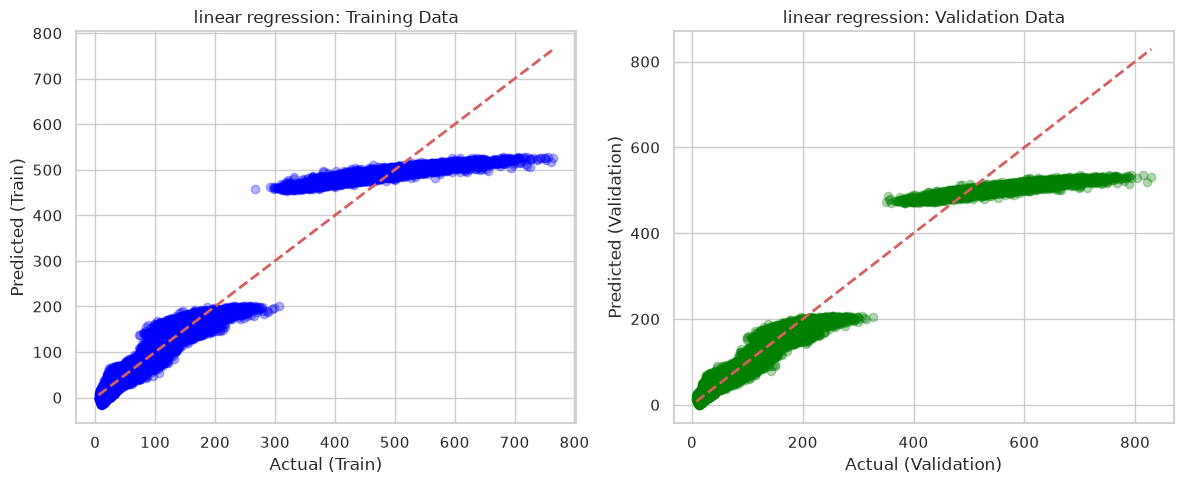

In [86]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, color='blue', alpha=0.3)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel("Actual (Train)")
plt.ylabel("Predicted (Train)")
plt.title("linear regression: Training Data")

plt.subplot(1, 2, 2)
plt.scatter(y_val, y_val_pred, color='green', alpha=0.3)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel("Actual (Validation)")
plt.ylabel("Predicted (Validation)")
plt.title("linear regression: Validation Data")
plt.tight_layout()
plt.show()

### 6.3 RandomForest

In [87]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

In [88]:
# Train on the full Train set (not a subsample) so the comparison against
# XGBoost/LightGBM/CatBoost - which all train on the full set - is fair.
rf_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [89]:
rf_pred = rf_model.predict(X_val_scaled)
rf_mae = mean_absolute_error(y_val, rf_pred)
rf_mse = mean_squared_error(y_val, rf_pred)
rf_r2 = r2_score(y_val, rf_pred)

In [90]:
print(f"\n--- Random Forest (Validation) ---")
print(f"MAE: {rf_mae:.3f}")
print(f"MSE: {rf_mse:.3f}")
print(f"R2 : {rf_r2:.3f}")


--- Random Forest (Validation) ---
MAE: 7.427
MSE: 174.547
R2 : 0.984


In [91]:
sample_size = 1000

In [92]:
y_train_pred = rf_model.predict(X_train_scaled[:sample_size])
y_val_pred = rf_model.predict(X_val_scaled[:sample_size])

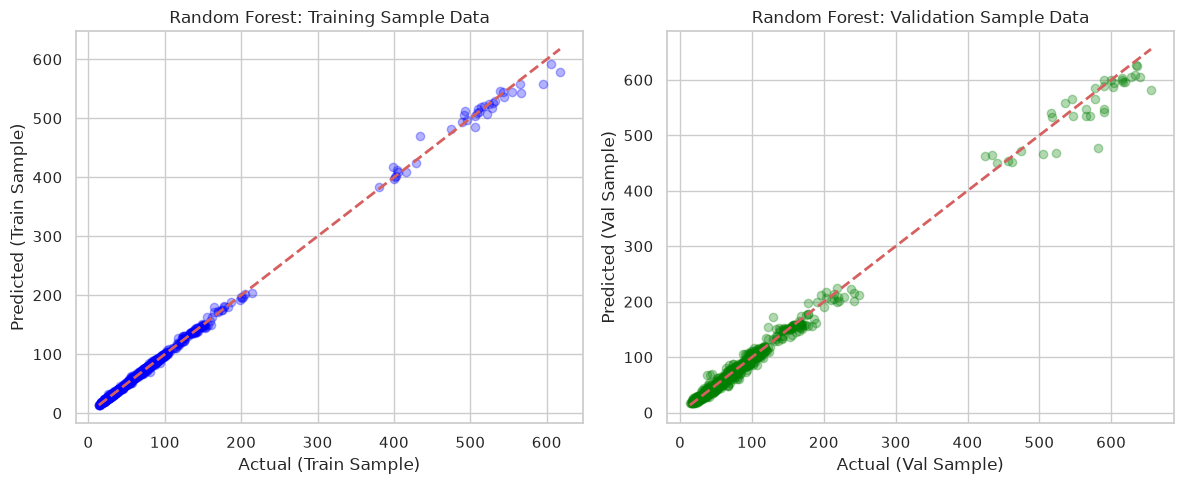

In [93]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train[:sample_size], y_train_pred, color='blue', alpha=0.3)
plt.plot([y_train[:sample_size].min(), y_train[:sample_size].max()],
         [y_train[:sample_size].min(), y_train[:sample_size].max()], 'r--', lw=2)
plt.xlabel("Actual (Train Sample)")
plt.ylabel("Predicted (Train Sample)")
plt.title("Random Forest: Training Sample Data")

plt.subplot(1, 2, 2)
plt.scatter(y_val[:sample_size], y_val_pred, color='green', alpha=0.3)
plt.plot([y_val[:sample_size].min(), y_val[:sample_size].max()],
         [y_val[:sample_size].min(), y_val[:sample_size].max()], 'r--', lw=2)
plt.xlabel("Actual (Val Sample)")
plt.ylabel("Predicted (Val Sample)")
plt.title("Random Forest: Validation Sample Data")

plt.tight_layout()
plt.show()

In [94]:
def evaluate_model(model, X_train, y_train, X_val, y_val, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    mae = mean_absolute_error(y_val, pred)
    mse = mean_squared_error(y_val, pred)
    r2 = r2_score(y_val, pred)
    print(f"\n--- {name} (Validation) ---")
    print(f"MAE: {mae:.3f}")
    print(f"MSE: {mse:.3f}")
    print(f"R2 : {r2:.3f}")
    return {"Model": name, "MAE": mae, "MSE": mse, "R2": r2}


In [95]:
results = []

### 6.4 KNN

In [96]:
knn_model = KNeighborsRegressor(n_neighbors=5)
results.append(evaluate_model(knn_model, X_train_scaled, y_train, X_val_scaled, y_val, "KNN"))


--- KNN (Validation) ---
MAE: 8.405
MSE: 218.081
R2 : 0.980


In [97]:
y_train_pred = knn_model.predict(X_train_scaled)
y_val_pred = knn_model.predict(X_val_scaled)

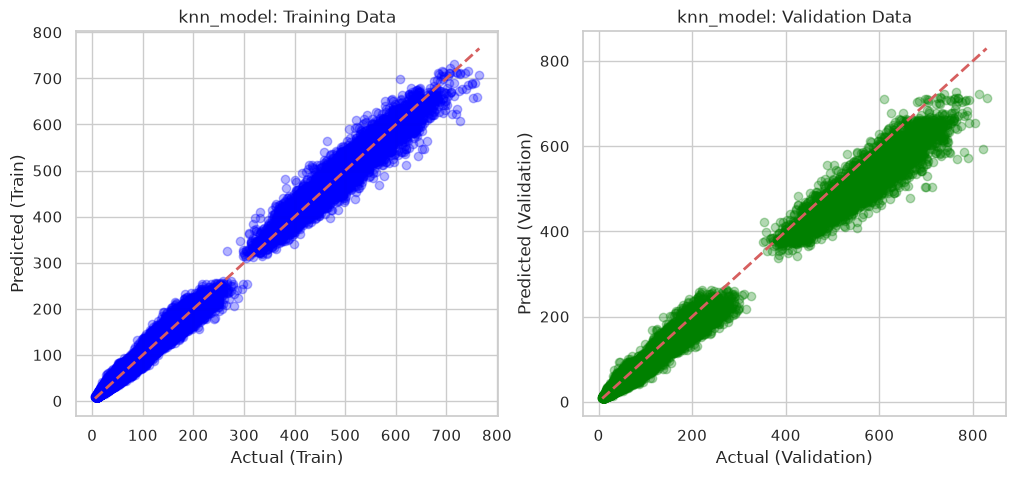

In [98]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, color='blue', alpha=0.3)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel("Actual (Train)")
plt.ylabel("Predicted (Train)")
plt.title("knn_model: Training Data")

plt.subplot(1, 2, 2)
plt.scatter(y_val, y_val_pred, color='green', alpha=0.3)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel("Actual (Validation)")
plt.ylabel("Predicted (Validation)")
plt.title("knn_model: Validation Data")
plt.show()

### 6.5 Decision tree

In [99]:
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
results.append(evaluate_model(dt_model, X_train_scaled, y_train, X_val_scaled, y_val, "Decision Tree"))


--- Decision Tree (Validation) ---
MAE: 11.442
MSE: 317.580
R2 : 0.970


In [100]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

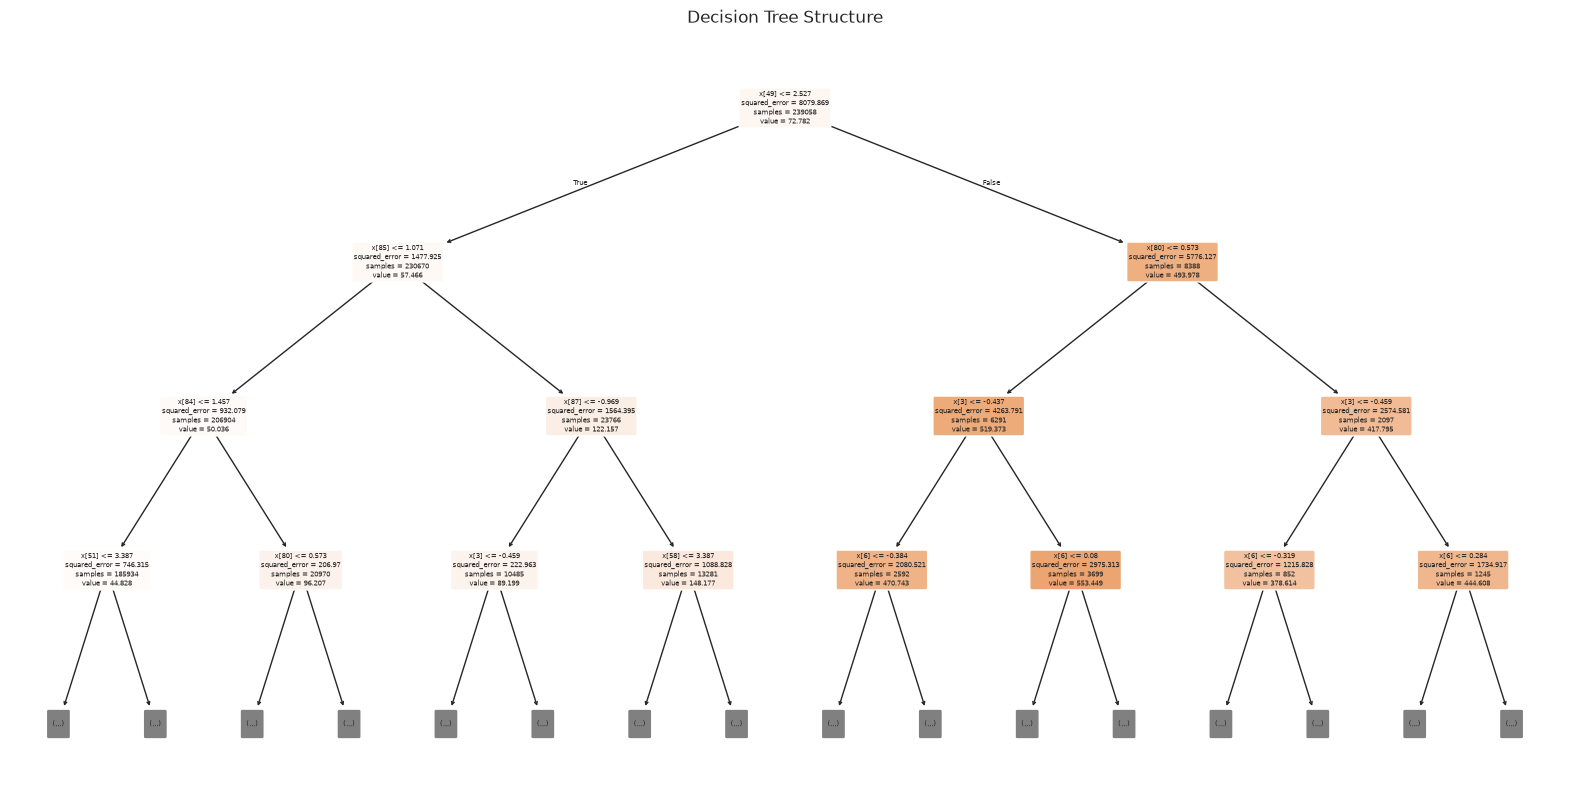

In [101]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model,

          filled=True,
          max_depth=3,
          rounded=True)
plt.title("Decision Tree Structure")
plt.show()

In [102]:
y_train_pred = dt_model.predict(X_train_scaled)
y_val_pred = dt_model.predict(X_val_scaled)

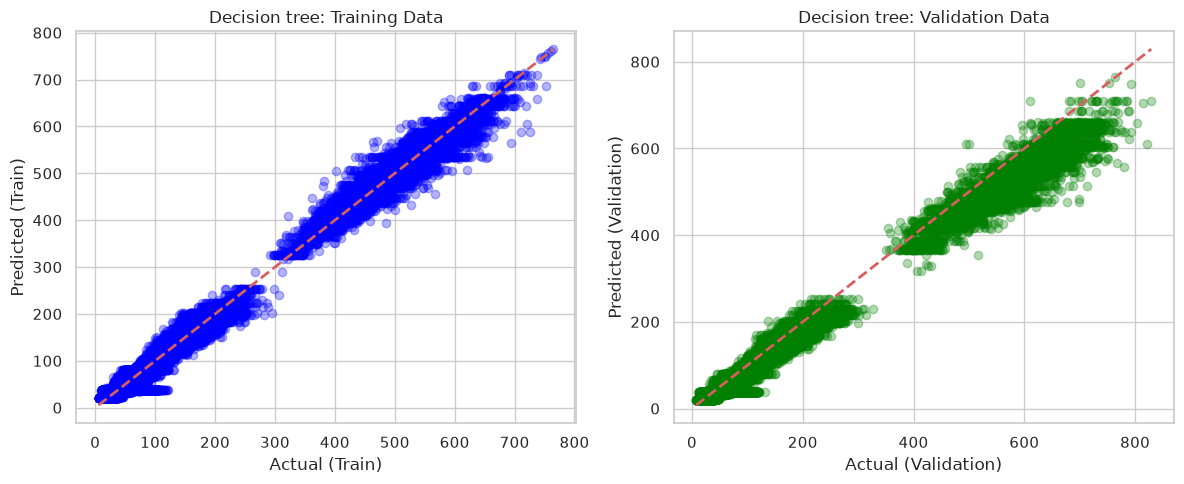

In [103]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, color='blue', alpha=0.3)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel("Actual (Train)")
plt.ylabel("Predicted (Train)")
plt.title("Decision tree: Training Data")

plt.subplot(1, 2, 2)
plt.scatter(y_val, y_val_pred, color='green', alpha=0.3)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel("Actual (Validation)")
plt.ylabel("Predicted (Validation)")
plt.title("Decision tree: Validation Data")
plt.tight_layout()
plt.show()

### 6.6 XGBoost

In [104]:
# 3) XGBoost
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)
results.append(evaluate_model(xgb_model, X_train_scaled, y_train, X_val_scaled, y_val, "XGBoost"))


--- XGBoost (Validation) ---
MAE: 6.970
MSE: 155.418
R2 : 0.986


In [105]:
y_train_pred = xgb_model.predict(X_train_scaled)
y_val_pred = xgb_model.predict(X_val_scaled)

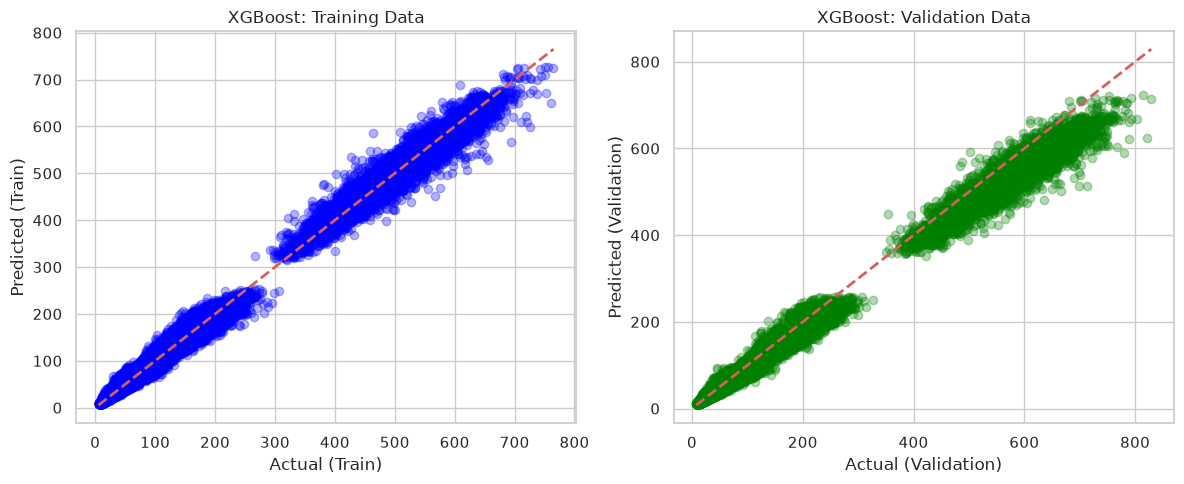

In [106]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, color='blue', alpha=0.3)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel("Actual (Train)")
plt.ylabel("Predicted (Train)")
plt.title("XGBoost: Training Data")

plt.subplot(1, 2, 2)
plt.scatter(y_val, y_val_pred, color='green', alpha=0.3)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel("Actual (Validation)")
plt.ylabel("Predicted (Validation)")
plt.title("XGBoost: Validation Data")

plt.tight_layout()
plt.show()

### 6.7 LightGBM

In [107]:
lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42, verbose=-1)
results.append(evaluate_model(lgbm_model, X_train_scaled, y_train, X_val_scaled, y_val, "LightGBM"))


--- LightGBM (Validation) ---
MAE: 6.970
MSE: 158.839
R2 : 0.985


In [108]:
y_train_pred = lgbm_model.predict(X_train_scaled)
y_val_pred = lgbm_model.predict(X_val_scaled)

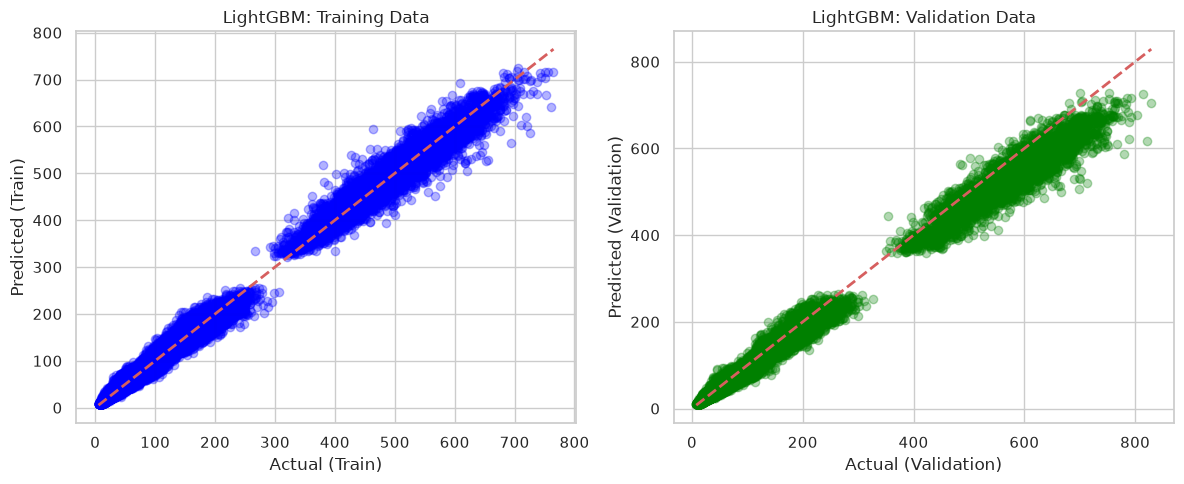

In [109]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, color='blue', alpha=0.3)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel("Actual (Train)")
plt.ylabel("Predicted (Train)")
plt.title("LightGBM: Training Data")

plt.subplot(1, 2, 2)
plt.scatter(y_val, y_val_pred, color='green', alpha=0.3)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel("Actual (Validation)")
plt.ylabel("Predicted (Validation)")
plt.title("LightGBM: Validation Data")
plt.tight_layout()
plt.show()

### 6.8 Catboost

In [110]:
catboost_model = CatBoostRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42, verbose=0)
results.append(evaluate_model(catboost_model, X_train_scaled, y_train, X_val_scaled, y_val, "CatBoost"))


--- CatBoost (Validation) ---
MAE: 7.592
MSE: 180.095
R2 : 0.983


In [111]:
y_train_pred =catboost_model.predict(X_train_scaled)
y_val_pred = catboost_model.predict(X_val_scaled)

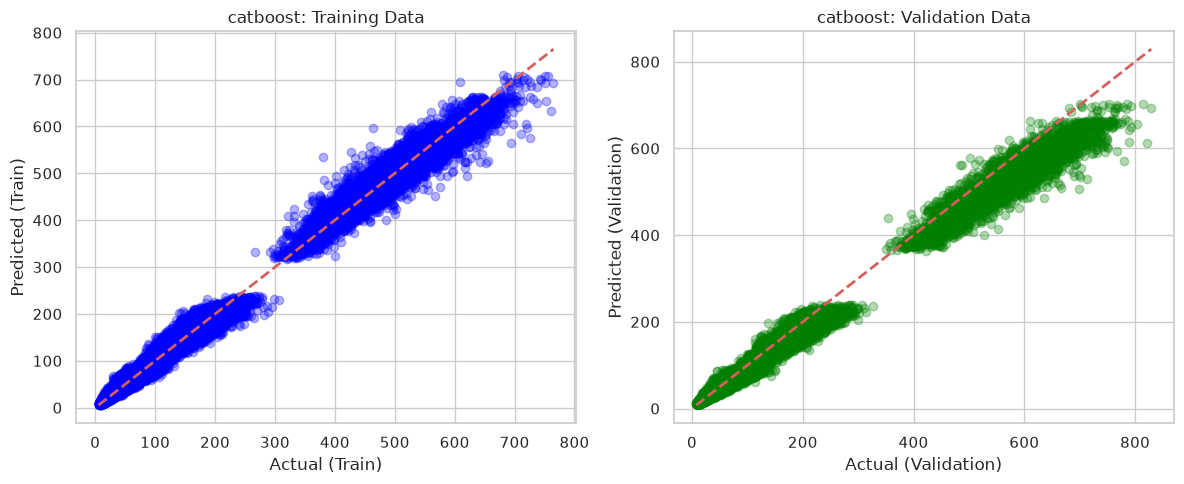

In [112]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, color='blue', alpha=0.3)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel("Actual (Train)")
plt.ylabel("Predicted (Train)")
plt.title("catboost: Training Data")

plt.subplot(1, 2, 2)
plt.scatter(y_val, y_val_pred, color='green', alpha=0.3)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel("Actual (Validation)")
plt.ylabel("Predicted (Validation)")
plt.title("catboost: Validation Data")
plt.tight_layout()
plt.show()

In [113]:
results.append({"Model": "Linear Regression", "MAE": lr_mae, "MSE": lr_mse, "R2": lr_r2})
results.append({"Model": "Random Forest", "MAE": rf_mae, "MSE": rf_mse, "R2": rf_r2})

In [114]:
all_comparison_df = pd.DataFrame(results)

In [115]:
all_comparison_df_sorted = all_comparison_df.sort_values(by='R2', ascending=False).reset_index(drop=True)

In [116]:
print("--- COMPREHENSIVE 7-MODELS COMPARISON ---")
display(all_comparison_df_sorted)

--- COMPREHENSIVE 7-MODELS COMPARISON ---


,Model,MAE,MSE,R2
0,XGBoost,6.97,155.42,0.99
1,LightGBM,6.97,158.84,0.99
2,Random Forest,7.43,174.55,0.98
3,CatBoost,7.59,180.10,0.98
4,KNN,8.41,218.08,0.98
5,Decision Tree,11.44,317.58,0.97
6,Linear Regression,10.50,436.69,0.96


In [117]:
print("-" * 50)

--------------------------------------------------


In [118]:
best_model = all_comparison_df_sorted.loc[0, 'Model']
best_score = all_comparison_df_sorted.loc[0, 'R2']
print(f" The Best Model is: {best_model} (R2 = {best_score:.3f})")

 The Best Model is: XGBoost (R2 = 0.986)


In [119]:
# Everything above was tuned/compared using the Validation set only.
# The Test set has not been touched yet - run it once, here, for an
# unbiased read on how the chosen model generalizes.
fitted_models = {
    "Linear Regression": lr_model,
    "Random Forest": rf_model,
    "KNN": knn_model,
    "Decision Tree": dt_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "CatBoost": catboost_model,
}
final_model = fitted_models[best_model]

In [120]:
# Sanity check: is the model relying on one dominant feature (a sign of
# more hidden leakage), or is importance spread across many features
# (a sign the high R2 reflects the dataset's structure, not a shortcut)?
if hasattr(final_model, "feature_importances_"):
    importances = pd.Series(
        final_model.feature_importances_, index=X_train.columns
    ).sort_values(ascending=False)
    print("Top 15 feature importances for the winning model:")
    print(importances.head(15))
    print(f"Top feature accounts for {importances.iloc[0] / importances.sum():.1%} of total importance")


Top 15 feature importances for the winning model:
Commodity_Beef          0.72
Category_Protein        0.06
Category_Oils           0.05
Commodity_Cheese        0.04
Commodity_Eggs          0.03
Category_Legumes        0.03
Category_Vegetables     0.01
Category_Grains         0.01
Commodity_Garlic        0.01
Commodity_Yogurt        0.01
Commodity_Chicken       0.00
Commodity_Watermelon    0.00
Market_Type_Wholesale   0.00
Commodity_Orange        0.00
Category_Fruits         0.00
dtype: float32
Top feature accounts for 71.9% of total importance


In [122]:
# If one Commodity dummy dominates importance, confirm it's because prices
# genuinely differ by an order of magnitude across commodities (expected),
# not a data quirk.
print("Price range (EGP) by commodity - sanity check for the importance above:")

print(
    df.groupby("Commodity", observed=True)["Price_EGP"]
      .agg(["min", "median", "max"])
      .sort_values("median", ascending=False)
)

Price range (EGP) by commodity - sanity check for the importance above:
                 min  median    max
Commodity                          
Beef          267.31  540.10 891.93
Fish           73.53  188.66 371.89
Cheese         89.58  158.44 254.48
Chicken        73.29  146.93 262.85
Sunflower Oil  58.38  112.60 186.94
Vegetable Oil  53.76  102.67 160.33
Soybean Oil    57.21  102.53 173.05
Eggs           48.20   97.45 186.45
Chickpeas      46.30   90.11 153.46
Lentils        42.46   81.87 132.80
Yogurt         44.47   78.88 133.51
Apple          35.93   76.24 139.46
Mango          15.14   67.06 156.12
Garlic         27.39   62.90 115.12
Beans          37.43   60.13  92.29
Milk           26.46   51.02  84.82
Grapes         11.59   49.17 113.88
Pasta          27.20   47.10  75.93
Rice           24.25   43.89  73.96
Guava          13.57   41.51  89.29
Banana         18.62   40.20  75.89
Flour          22.23   38.06  61.61
Pepper          8.93   36.42  83.93
Wheat          17.59   33.63

In [123]:
test_pred = final_model.predict(X_test_scaled)
test_mae = mean_absolute_error(y_test, test_pred)
test_mse = mean_squared_error(y_test, test_pred)
test_r2 = r2_score(y_test, test_pred)

In [124]:
print(f"\n=== Final Test Set Evaluation ({best_model}) ===")
print(f"Test MAE: {test_mae:.3f}")
print(f"Test MSE: {test_mse:.3f}")
print(f"Test R2 : {test_r2:.3f}")


=== Final Test Set Evaluation (XGBoost) ===
Test MAE: 13.542
Test MSE: 527.423
Test R2 : 0.959


In [125]:
import joblib
joblib.dump(final_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("\nSaved the winning model to best_model.pkl and the scaler to scaler.pkl")


Saved the winning model to best_model.pkl and the scaler to scaler.pkl


## 7. Model Comparison

The models are compared using MAE, MSE, and R² to identify the best-performing model.

In [126]:
import matplotlib.pyplot as plt
import numpy as np

In [127]:
# Pull the numbers straight from the results computed above instead of
# retyping them by hand, so the chart can never drift out of sync.
plot_df = all_comparison_df_sorted
models = plot_df['Model'].tolist()
mae = plot_df['MAE'].tolist()
mse = plot_df['MSE'].tolist()
r2 = plot_df['R2'].tolist()

In [128]:
x = np.arange(len(models))
width = 0.25

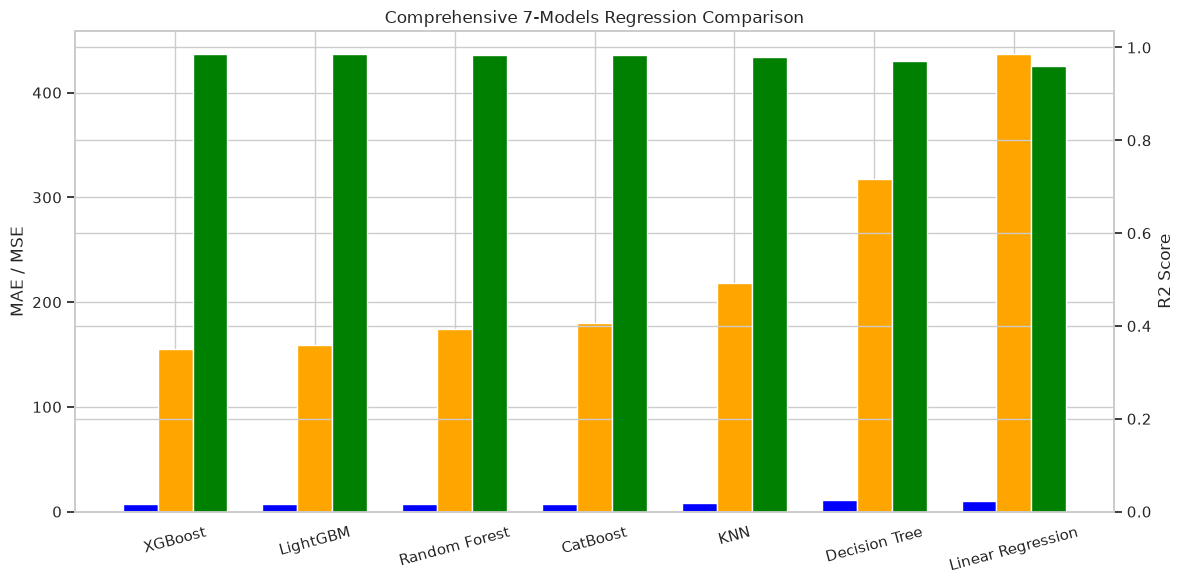

In [129]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.bar(x - width, mae, width, label='MAE', color='blue')
ax1.bar(x, mse, width, label='MSE', color='orange')
ax2.bar(x + width, r2, width, label='R2', color='green')

ax1.set_ylabel('MAE / MSE')
ax2.set_ylabel('R2 Score')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=15)
ax1.set_title('Comprehensive 7-Models Regression Comparison')

fig.tight_layout()
plt.show()

## 8. New Product Price Prediction

The final model is used to predict the price of a new food product based
on its location, commodity, market, supply, demand, and other features.

In [130]:
import pandas as pd

In [131]:
new_product_data = {
    'Year': 2026,
    'Month': 9,
    'Season': 'Fall',
    'Is_Ramadan': 1,
    'Annual_Sin': 0.5,
    'Annual_Cos': 0.86,
    'Governorate': 'cairo',
    'Region': 'Northern',
    'Market_Type': 'Retail',
    'Unit': 'KG',
    'Urbanization': 0.96,
    'Commodity': 'Beans',
    'Category': 'Legumes',
    'Inflation_Index': 103.57,
    'Supply_Level': 76.10,
    'Demand_Level': 90.09,
    'Transport_Cost': 5.26,
}  # Historical_Median removed - it's no longer a model feature

In [132]:
new_df = pd.DataFrame([new_product_data])

In [133]:
new_encoded = pd.get_dummies(new_df, columns=['Season','Governorate','Region','Commodity','Market_Type','Category','Unit'])

In [134]:
new_encoded = new_encoded.reindex(columns=X_train.columns, fill_value=0)

In [135]:
new_scaled = scaler.transform(new_encoded)

In [136]:
predicted_price = final_model.predict(new_scaled)[0]

In [137]:
print("---  New Product Price Prediction ---")
print(f"Product: {new_product_data['Commodity']} in {new_product_data['Governorate']}")
print(f"Predicted Price: {predicted_price:.2f} EGP")

---  New Product Price Prediction ---
Product: Beans in cairo
Predicted Price: 61.94 EGP
